# **1. Mount & Extract**

In [ ]:
from google.colab import drive
from pathlib import Path
import zipfile

drive.mount("/content/drive")

ZIP_PATH     = Path("/content/drive/MyDrive/Betta_Classification/dataset_clean.zip")
EXTRACT_PATH = Path("/content/dataset")
BASE_DIR     = EXTRACT_PATH / "dataset_clean"

if not BASE_DIR.exists():
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(EXTRACT_PATH)

print("Extraction complete. Classes found:", [d.name for d in BASE_DIR.iterdir() if d.is_dir()])

Mounted at /content/drive
Extraction complete. Classes found: ['Veiltail', 'Double_Tail', 'Plakat']


# **2. Stratified Split**

In [ ]:
!pip install split-folders -q

import splitfolders

OUTPUT_DIR = Path("/content/dataset_split")

splitfolders.ratio(
    str(BASE_DIR),
    output=str(OUTPUT_DIR),
    seed=42,
    ratio=(0.70, 0.15, 0.15),
)

for split in ("train", "val", "test"):
    split_path = OUTPUT_DIR / split
    total = sum(len(files) for _, _, files in split_path.walk())
    print(f"  {split.upper():<5}  {total} images")

Copying files: 300 files [00:00, 1476.37 files/s]

  TRAIN  210 images
  VAL    45 images
  TEST   45 images


# **3. Data Pipeline**

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import preprocess_input

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE


def build_dataset(directory: str, training: bool) -> tuple[tf.data.Dataset, list[str]]:
    """
    Build a tf.data pipeline with VGG16-compatible preprocessing.

    VGG16 requires BGR channel order and zero-centering against ImageNet mean,
    applied via preprocess_input. No internal rescaling layer exists in VGG16.

    Args:
        directory: Path to the split directory (train / val / test).
        training:  If True, applies augmentation and shuffles.

    Returns:
        Tuple of (prefetched dataset, class_names list).
        class_names must be extracted here — attribute lost after prefetch wrapping.
    """
    raw_ds = tf.keras.utils.image_dataset_from_directory(
        directory,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=training,
        seed=42,
        label_mode="categorical",
    )

    # Extract before any chaining — attribute unavailable on _PrefetchDataset
    class_names = raw_ds.class_names
    ds = raw_ds

    if training:
        augment = tf.keras.Sequential([
            tf.keras.layers.RandomFlip("horizontal"),
            tf.keras.layers.RandomRotation(0.10),
            tf.keras.layers.RandomZoom(0.10),
            tf.keras.layers.RandomTranslation(0.08, 0.08),
            # Brightness/contrast shift forces the model to rely on shape not color
            tf.keras.layers.RandomBrightness(0.15),
            tf.keras.layers.RandomContrast(0.15),
        ])
        ds = ds.map(
            lambda x, y: (augment(x, training=True), y),
            num_parallel_calls=AUTOTUNE,
        )

    # VGG16 requires RGB→BGR conversion and ImageNet mean subtraction
    ds = ds.map(
        lambda x, y: (preprocess_input(x), y),
        num_parallel_calls=AUTOTUNE,
    )
    return ds.prefetch(AUTOTUNE), class_names


train_ds, class_names = build_dataset(str(OUTPUT_DIR / "train"), training=True)
val_ds,   _           = build_dataset(str(OUTPUT_DIR / "val"),   training=False)
test_ds,  _           = build_dataset(str(OUTPUT_DIR / "test"),  training=False)

print("Class mapping:", class_names)

Found 210 files belonging to 3 classes.
Found 45 files belonging to 3 classes.
Found 45 files belonging to 3 classes.
Class mapping: ['Double_Tail', 'Plakat', 'Veiltail']


# **4. Model Architecture**

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

NUM_CLASSES = len(class_names)

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3),
)
base_model.trainable = False

# GlobalAveragePooling2D instead of Flatten — Flatten on VGG16 produces ~25M
# dense parameters, causing immediate OOM crash on Colab T4 GPU
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(64, activation="relu")(x)  # bottleneck reduces overfitting on small dataset
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)
model.summary(line_length=80)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)        │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)             │ (None, 224, 224, 64)     │         1,792 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)             │ (None, 224, 224, 64)     │        36,928 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)        │ (None, 112, 112, 64)     │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)             │ (None, 112, 112, 128)    │        73,856 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)             │ (None, 112, 112, 128)    │       147,584 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)        │ (None, 56, 56, 128)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)             │ (None, 56, 56, 256)      │       295,168 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)             │ (None, 56, 56, 256)      │       590,080 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)             │ (None, 56, 56, 256)      │       590,080 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)        │ (None, 28, 28, 256)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)             │ (None, 28, 28, 512)      │     1,180,160 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)             │ (None, 28, 28, 512)      │     2,359,808 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)             │ (None, 28, 28, 512)      │     2,359,808 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)        │ (None, 14, 14, 512)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)             │ (None, 14, 14, 512)      │     2,359,808 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)             │ (None, 14, 14, 512)      │     2,359,808 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)             │ (None, 14, 14, 512)      │     2,359,808 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)        │ (None, 7, 7, 512)        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ global_average_pooling2d          │ (None, 512)              │             0 │
│ (GlobalAveragePooling2D)          │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense (Dense)                     │ (None, 64)               │        32,832 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │ (None, 64)               │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_1 (Dense)                   │ (None, 3)                │           195 │
└──────────────────────────────

 Total params: 14,747,715 (56.26 MB)

 Trainable params: 33,027 (129.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

# **5. Classifier Warmup**

In [ ]:
import os
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

os.makedirs("/content/models",  exist_ok=True)
os.makedirs("/content/results", exist_ok=True)

CHECKPOINT_PATH = "/content/models/03_vgg16.keras"

print("\nPHASE 1: Classifier head warmup — base model frozen")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

# Warmup phase is short; early stopping protects against head overfitting
warmup_callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
]

history_warmup = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=warmup_callbacks,
    verbose=1,
)


PHASE 1: Classifier head warmup — base model frozen
Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 50s 4s/step - accuracy: 0.3238 - loss: 3.5363 - val_accuracy: 0.5556 - val_loss: 1.1494
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.5905 - loss: 1.6254 - val_accuracy: 0.7778 - val_loss: 0.4551
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.6476 - loss: 1.2526 - val_accuracy: 0.8444 - val_loss: 0.3672
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 768ms/step - accuracy: 0.6619 - loss: 0.8964 - val_accuracy: 0.8889 - val_loss: 0.3437
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7381 - loss: 0.6863 - val_accuracy: 0.8889 - val_loss: 0.2895
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 929ms/step - accuracy: 0.7857 - loss: 0.5926 - val_accuracy: 0.8889 - val_loss: 0.3213
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 907ms/step - accuracy: 0.7905 - loss: 0.5429 - val_accuracy: 0.8889 - val_loss: 0.3572
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.8571 - loss: 0

# **6. Fine-Tuning**

In [ ]:
print("\nPHASE 2: Fine-tuning Block 5 (last 4 convolutional layers)")
base_model.trainable = True

# VGG16 has 19 layers total — unfreeze Block 5 only (layers 15 onward)
# to adapt high-level feature detectors to betta fin morphology
for layer in base_model.layers[:15]:
    layer.trainable = False

print(f"Trainable layers: {sum(1 for l in model.layers if l.trainable)}/{len(model.layers)}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

finetune_callbacks = [
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ModelCheckpoint(CHECKPOINT_PATH, monitor="val_accuracy", save_best_only=True, mode="max"),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-7, verbose=1),
]

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=finetune_callbacks,
    verbose=1,
)


PHASE 2: Fine-tuning Block 5 (last 4 convolutional layers)
Trainable layers: 8/23
Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.7762 - loss: 0.5918 - val_accuracy: 0.8889 - val_loss: 0.2551 - learning_rate: 1.0000e-05
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 944ms/step - accuracy: 0.8238 - loss: 0.4713 - val_accuracy: 0.8889 - val_loss: 0.2602 - learning_rate: 1.0000e-05
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7810 - loss: 0.4507 - val_accuracy: 0.9111 - val_loss: 0.2841 - learning_rate: 1.0000e-05
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 931ms/step - accuracy: 0.8429 - loss: 0.4487 - val_accuracy: 0.8889 - val_loss: 0.2458 - learning_rate: 1.0000e-05
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 884ms/step - accuracy: 0.8762 - loss: 0.2858 - val_accuracy: 0.8889 - val_loss: 0.2416 - learning_rate: 1.0000e-05
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.8571 - loss: 0.3087 - val_accuracy: 0.9111 - val_loss: 0.1958 - learning_rate: 1.0000e-05


# **7. Training Curve**

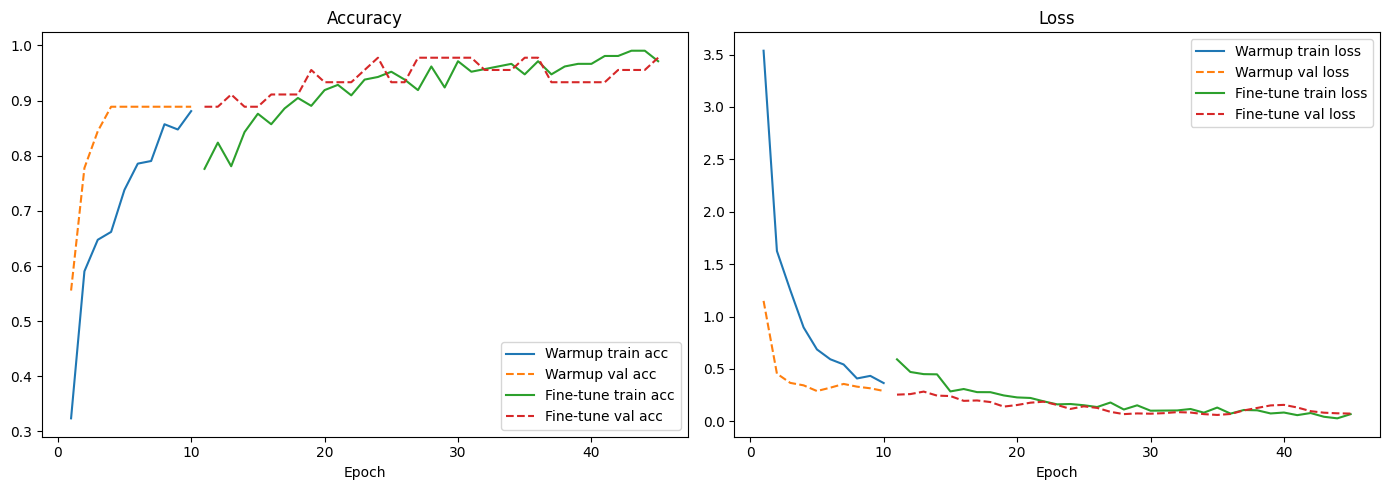

In [ ]:
import matplotlib.pyplot as plt

def plot_history(histories: list, labels: list) -> None:
    """Plot combined accuracy and loss curves across training phases."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    offset = 0
    for hist, label in zip(histories, labels):
        epochs = range(offset + 1, offset + len(hist.history["accuracy"]) + 1)
        axes[0].plot(epochs, hist.history["accuracy"],     label=f"{label} train acc")
        axes[0].plot(epochs, hist.history["val_accuracy"], label=f"{label} val acc",   linestyle="--")
        axes[1].plot(epochs, hist.history["loss"],         label=f"{label} train loss")
        axes[1].plot(epochs, hist.history["val_loss"],     label=f"{label} val loss",  linestyle="--")
        offset += len(hist.history["accuracy"])

    axes[0].set_title("Accuracy"); axes[0].legend(); axes[0].set_xlabel("Epoch")
    axes[1].set_title("Loss");     axes[1].legend(); axes[1].set_xlabel("Epoch")
    plt.tight_layout()
    plt.savefig("/content/results/03_training_curves.png", dpi=150)
    plt.show()

plot_history([history_warmup, history_finetune], ["Warmup", "Fine-tune"])

# **8. Evaluation**


Test set benchmark (best checkpoint weights)
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 571ms/step - accuracy: 0.9556 - loss: 0.0954

  Test Accuracy : 95.56%
  Test Loss     : 0.0954
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 954ms/step

Classification Report
              precision    recall  f1-score   support

 Double_Tail      1.000     0.933     0.966        15
      Plakat      0.933     0.933     0.933        15
    Veiltail      0.938     1.000     0.968        15

    accuracy                          0.956        45
   macro avg      0.957     0.956     0.956        45
weighted avg      0.957     0.956     0.956        45



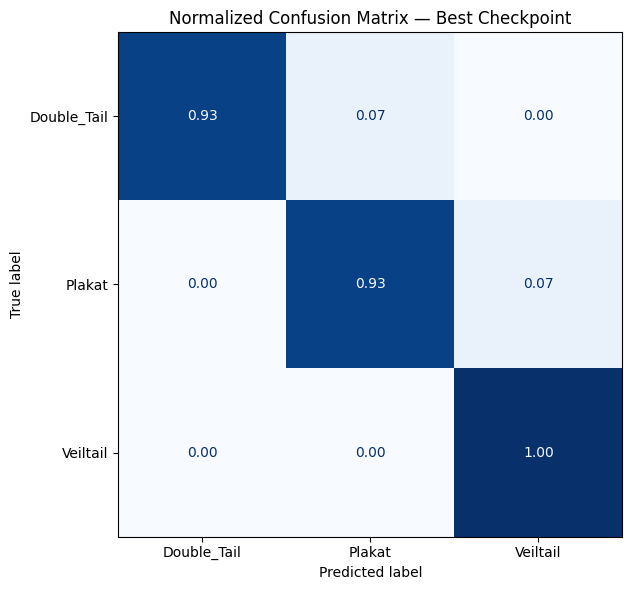

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Load best weights — evaluates the checkpoint, not the last epoch
best_model = tf.keras.models.load_model(CHECKPOINT_PATH)

print("\nTest set benchmark (best checkpoint weights)")
test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)
print(f"\n  Test Accuracy : {test_acc * 100:.2f}%")
print(f"  Test Loss     : {test_loss:.4f}")

# Rebuild ground-truth labels from the unshuffled test dataset
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_true = np.argmax(y_true, axis=1)

y_prob = best_model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

print("\nClassification Report")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

# Normalized confusion matrix reveals per-class recall at a glance
cm = confusion_matrix(y_true, y_pred, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format=".2f")
ax.set_title("Normalized Confusion Matrix — Best Checkpoint")
plt.tight_layout()
plt.savefig("/content/results/03_confusion_matrix.png", dpi=150)
plt.show()

# **9. Export**

In [ ]:
TFLITE_PATH = "/content/models/03_vgg16_f16.tflite"

converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

tflite_model = converter.convert()

with open(TFLITE_PATH, "wb") as f:
    f.write(tflite_model)

size_mb = len(tflite_model) / (1024 ** 2)
print(f"TFLite model exported: {TFLITE_PATH}  ({size_mb:.2f} MB)")

Saved artifact at '/tmp/tmpbvxfxzwe'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  132412370275600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132412370276176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132412370277136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132412370276368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132412370277520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132412370277328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132412370277904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132412370277712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132412370278288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132412370278096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1324123702786

# **10. Download**

In [ ]:
from google.colab import files

files.download("/content/models/03_vgg16.keras")
files.download("/content/models/03_vgg16_f16.tflite")
files.download("/content/results/03_training_curves.png")
files.download("/content/results/03_confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>